In [1]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
from keras.src import datasets, layers, models
fashion_mnist = keras.src.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print(train_images.shape)


(60000, 28, 28)


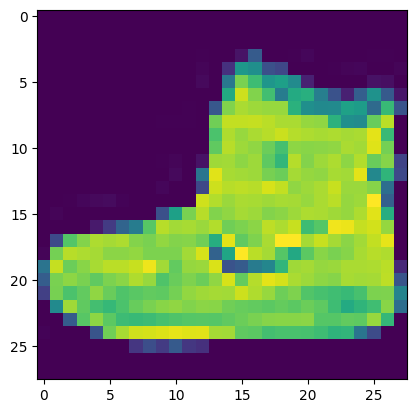

In [2]:
plt.imshow(train_images[0])

# train_images = train_images / 255.0
# test_images = test_images / 255.0

In [14]:

import numpy as np
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
train_images = scaler.fit_transform(train_images.reshape(-1, 28*28))
test_images = scaler.transform(test_images.reshape(-1, 28*28))
# -1은 자동으로 행의 수를 계산하도록 하는 의미입니다.
#  reshape(-1, 28*28)은 28x28 크기의 이미지를 784차원 벡터로 변환하는 것을 의미합니다.



In [15]:
input_layer=tf.keras.layers.Input(shape=(28*28,))  # 입력층

hidden_layer=tf.keras.layers.Dense(units=512, activation='relu') # 은닉층
output_layer=tf.keras.layers.Dense(units=10, activation='softmax') # 출력층
fashion_item=tf.keras.models.Sequential()


In [16]:
fashion_item.add(input_layer)
fashion_item.add(keras.layers.Flatten()) # 28*28 형태의 이미지를 784차원으로 평탄화
fashion_item.add(hidden_layer)
fashion_item.add(output_layer)
fashion_item.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
fashion_item.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [18]:
from tensorflow.keras.utils import to_categorical

train_labels_encoded = to_categorical(train_labels, num_classes=10)
test_labels_encoded = to_categorical(test_labels, num_classes=10)
print(train_labels_encoded[0])



[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [19]:
fashion_item.fit(train_images, train_labels_encoded, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - categorical_accuracy: 0.7934 - loss: 0.5852
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - categorical_accuracy: 0.8689 - loss: 0.3623
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - categorical_accuracy: 0.8824 - loss: 0.3242
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - categorical_accuracy: 0.8898 - loss: 0.3008
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - categorical_accuracy: 0.8967 - loss: 0.2795
